**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 7**  
**Producto:** Rosas frescas cortadas, **HS 060311** (la variedad Freedom no se separa en las estadísticas; los indicadores se leen a nivel de categoría, como advierte la ficha)  
**Ficha técnica de referencia:** *Equipo 7 — Ficha técnica del estudio* (septiembre de 2026)

***

## La pregunta del equipo

> ¿Qué mercados de destino ofrecen la mejor combinación entre ventaja comparativa revelada, participación y crecimiento de la demanda, especialización exportadora y riesgo controlable para la Rosa Freedom colombiana?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Series por destino y CAGR** | ¿Hacia dónde van las rosas colombianas y cómo ha cambiado en diez años? |
| **HHI y CR3 de destinos** | ¿De cuántos mercados depende realmente la rosa colombiana? |
| **Balanza Comercial Relativa (BCR)** | ¿Colombia es exportador neto puro de rosas? |
| **Participación de mercado por destino** | ¿Qué porción de las importaciones de rosas de cada destino es colombiana? |
| **Valor unitario (USD/t)** | ¿A qué precio implícito vende Colombia frente a sus competidores y en cada destino? |
| **Cuota en la oferta mundial** | ¿Qué lugar ocupa Colombia entre los exportadores de rosas? |
| **RCA, RSCA y NRCA** | ¿Colombia exporta proporcionalmente más rosas que el resto del mundo? |
| **Índice de Lafay** | ¿Las rosas van mejor que el promedio comercial de Colombia? |
| **Matriz de decisión 0-100 con sensibilidad** | ¿Qué mercado priorizar, y qué tan robusta es esa respuesta? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [1]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [2]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 7/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "exp_serie": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/colombias-exports-to-world-by-importer_060311.csv",
    "exp_2025": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/colombias-exports-to-world-in-2025-by-importer_060311.csv",
    "exp_all": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/colombias-exports-to-world-in-2025-by-importer_all.csv",
    "imp_2025": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/colombias-imports-from-world-in-2025-by-exporter_060311.csv",
    "imp_all": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/colombias-imports-from-world-in-2025-by-exporter_all.csv",
    "mundo_exp": "Proyectos finales/Grupo 7/datos/Datos_proyectobrief/exporting-countries-in-2025_060311.csv",
    "canasta_co_exp": "data/co_exp_productos_hs2_serie.xls",
    "canasta_co_imp": "data/co_imp_productos_hs2_serie.csv",
    "canasta_mundo_exp": "data/mundo_exp_productos_hs2_serie.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  9 archivos


In [3]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Descargando 9 archivos en una sola peticion...

  extraido: colombias-exports-to-world-by-importer_060311.csv
  extraido: colombias-exports-to-world-in-2025-by-importer_060311.csv
  extraido: colombias-exports-to-world-in-2025-by-importer_all.csv
  extraido: colombias-imports-from-world-in-2025-by-exporter_060311.csv
  extraido: colombias-imports-from-world-in-2025-by-exporter_all.csv
  extraido: exporting-countries-in-2025_060311.csv
  extraido: co_exp_productos_hs2_serie.xls
  extraido: co_imp_productos_hs2_serie.csv
  extraido: mundo_exp_productos_hs2_serie.csv
  ok    exp_serie      -> colombias-exports-to-world-by-importer_060311.csv
  ok    exp_2025       -> colombias-exports-to-world-in-2025-by-importer_060311.csv
  ok    exp_all        -> colombias-exports-to-world-in-2025-by-importer_all.csv
  ok    imp_2025       -> colombias-imports-from-world-in-2025-by-exporter_060311.csv
  ok    imp_all        -> colombias-imports-from-world-in-2025-by-exporter_all.csv
  ok    mundo_exp  

In [4]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [5]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def ibcr(exportaciones, importaciones):
    """Indice de Balanza Comercial Relativa: (X - M) / (X + M), entre -1 y +1."""
    exportaciones = np.asarray(exportaciones, dtype=float)
    importaciones = np.asarray(importaciones, dtype=float)
    comercio_total = exportaciones + importaciones
    return np.where(comercio_total > 0, (exportaciones - importaciones) / comercio_total, np.nan)

def rca_balassa(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """Ventaja Comparativa Revelada de Balassa (1965). Mayor que 1 = especializacion revelada."""
    participacion_pais  = np.asarray(x_pais, dtype=float)  / np.asarray(x_pais_total, dtype=float)
    participacion_mundo = np.asarray(x_mundo, dtype=float) / np.asarray(x_mundo_total, dtype=float)
    return participacion_pais / participacion_mundo


def rsca_laursen(rca):
    """RCA simetrico de Laursen: (RCA - 1) / (RCA + 1), entre -1 y +1, con 0 como punto neutro."""
    rca = np.asarray(rca, dtype=float)
    return (rca - 1) / (rca + 1)

def nrca(x_pais, x_pais_total, x_mundo, x_mundo_total):
    """NRCA de Yu, Cai y Leung (2009): distancia entre la exportacion observada y la neutral. Suma cero."""
    x_pais, x_mundo = np.asarray(x_pais, dtype=float), np.asarray(x_mundo, dtype=float)
    x_pais_total, x_mundo_total = float(x_pais_total), float(x_mundo_total)
    observado = x_pais / x_mundo_total
    neutral   = (x_pais_total * x_mundo) / (x_mundo_total ** 2)
    return observado - neutral

def lafay(x_pais, m_pais):
    """Indice de Lafay (1992) sobre una canasta completa: positivo = el producto va mejor que el promedio del pais."""
    x_pais = np.asarray(x_pais, dtype=float)
    m_pais = np.asarray(m_pais, dtype=float)
    comercio_producto = x_pais + m_pais
    comercio_total    = comercio_producto.sum()
    ibcr_producto = np.where(comercio_producto > 0, (x_pais - m_pais) / comercio_producto, 0)
    ibcr_nacional = (x_pais - m_pais).sum() / comercio_total
    peso_producto = comercio_producto / comercio_total
    return 100 * (ibcr_producto - ibcr_nacional) * peso_producto

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

def matriz_multicriterio(puntajes, pesos):
    """Pondera una tabla de puntajes (filas = criterios, columnas = mercados) con un diccionario de pesos.

    Devuelve la contribucion de cada criterio por mercado y el total, ordenado de mayor a menor.
    Los pesos se normalizan para que sumen 1, asi que puedes escribirlos en % o en fracciones.
    """
    pesos = pd.Series(pesos, dtype=float)
    pesos = pesos / pesos.sum()
    contribucion = puntajes.mul(pesos, axis=0)
    resultado = contribucion.T
    resultado["Total"] = resultado.sum(axis=1)
    return resultado.sort_values("Total", ascending=False)

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos

Seis descargas de Trade Map del equipo (HS 060311 y el total de todos los productos) y tres archivos del curso con la canasta por capítulo HS2, que aportan los totales mundiales que faltaban para Balassa y Lafay.

In [6]:
serie = leer_serie_trademap(ruta("exp_serie"))              # Colombia exporta rosas, por destino, 2016-2025
exp_2025 = leer_trademap(ruta("exp_2025"))                  # lo mismo, corte 2025 con indicadores
exp_all  = leer_trademap(ruta("exp_all"))                   # Colombia exporta TODO, por destino, 2025
imp_2025 = leer_trademap(ruta("imp_2025"))                  # Colombia importa rosas, por origen, 2025
imp_all  = leer_trademap(ruta("imp_all"))                   # Colombia importa TODO, 2025
mundo_exp = leer_trademap(ruta("mundo_exp"))                # exportadores mundiales de rosas, 2025

mundo_2025, destinos_2025 = separar_mundo(exp_2025)
mundo_oferta, exportadores = separar_mundo(mundo_exp)

print(f"Colombia exporto rosas por USD {mundo_2025['valor_kusd']:,.0f} miles en 2025 a {len(destinos_2025)} destinos")
print(f"El mundo exporto rosas por USD {mundo_oferta['valor_kusd']:,.0f} miles; {len(exportadores)} paises exportadores")
destinos_2025[["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_pct", "cuota_en_socio_pct", "crec_valor_5a_pct"]].head(10)

Colombia exporto rosas por USD 429,509 miles en 2025 a 77 destinos
El mundo exporto rosas por USD 3,830,991 miles; 173 paises exportadores


/tmp/ipykernel_526/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_526/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_526/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

,pais,valor_kusd,cantidad,valor_unitario,participacion_pct,cuota_en_socio_pct,crec_valor_5a_pct
0,Estados Unidos de América,333643,"47,359.0000","7,044.9800",77.6801,56.2147,4.0000
1,España,22287,"3,503.0000","6,362.2600",5.1889,37.5607,25.0000
2,Reino Unido,12759,"2,103.0000","6,067.0500",2.9706,6.9467,6.0000
3,Canadá,12121,"1,613.0000","7,514.5700",2.8221,53.0240,-1.0000
4,Polonia,7319,868.0000,"8,432.0300",1.7040,3.1061,9.0000
5,Países Bajos,6474,722.0000,"8,966.7600",1.5073,1.5702,-8.0000
6,"Corea, República de",4496,716.0000,"6,279.3300",1.0468,62.5907,24.0000
7,Brasil,3321,388.0000,"8,559.2800",0.7732,62.9948,35.0000
8,Kazajstán,2930,369.0000,"7,940.3800",0.6822,3.9432,14.0000
9,Rumania,2555,436.0000,"5,860.0900",0.5949,NaN,0.0000


In [7]:
canasta_co_exp    = leer_canasta(ruta("canasta_co_exp"))
canasta_co_imp    = leer_canasta(ruta("canasta_co_imp"))
canasta_mundo_exp = leer_canasta(ruta("canasta_mundo_exp"))

print("Capitulo 06 (plantas vivas y flores) en la canasta exportadora colombiana, USD miles:")
print(fila_canasta(canasta_co_exp, "06").round(0).to_string())
print("\nExportaciones mundiales totales (TOTAL), USD miles:")
print(fila_canasta(canasta_mundo_exp, "TOTAL").round(0).to_string())

Capitulo 06 (plantas vivas y flores) en la canasta exportadora colombiana, USD miles:
2021   1,756,097.0000
2022   2,082,840.0000
2023   2,115,150.0000
2024   2,385,846.0000
2025   2,439,529.0000

Exportaciones mundiales totales (TOTAL), USD miles:
2021   22,156,836,166.0000
2022   24,738,037,986.0000
2023   23,661,578,494.0000
2024   23,931,014,145.0000
2025   25,609,329,378.0000


***
# 2. Series por destino, 2016-2025, y CAGR

In [8]:
paises_serie = serie[serie["codigo"] != "000"]
top4 = paises_serie[paises_serie["anio"] == 2025].nlargest(4, "valor_kusd")["pais"].tolist()

series_top = (paises_serie.assign(grupo=lambda d: np.where(d["pais"].isin(top4), d["pais"], "Otros"))
                          .groupby(["anio", "grupo"])["valor_kusd"].sum()
                          .unstack("grupo")[top4 + ["Otros"]])
exportar(series_top.reset_index(), "g7_series_destinos")
series_top

grupo,Estados Unidos de América,España,Reino Unido,Canadá,Otros
anio,,,,,
2016,228932,7082,7822,11295,49133
2017,229158,7578,7283,10490,54896
2018,250067,8064,7404,11735,56518
2019,252838,8094,6424,10502,52435
2020,257068,6121,5676,8987,43942
2021,285360,9364,9397,11792,51398
2022,306306,11549,11549,13040,50296
2023,294578,13126,10934,11552,45474
2024,333191,19097,11067,11307,50435


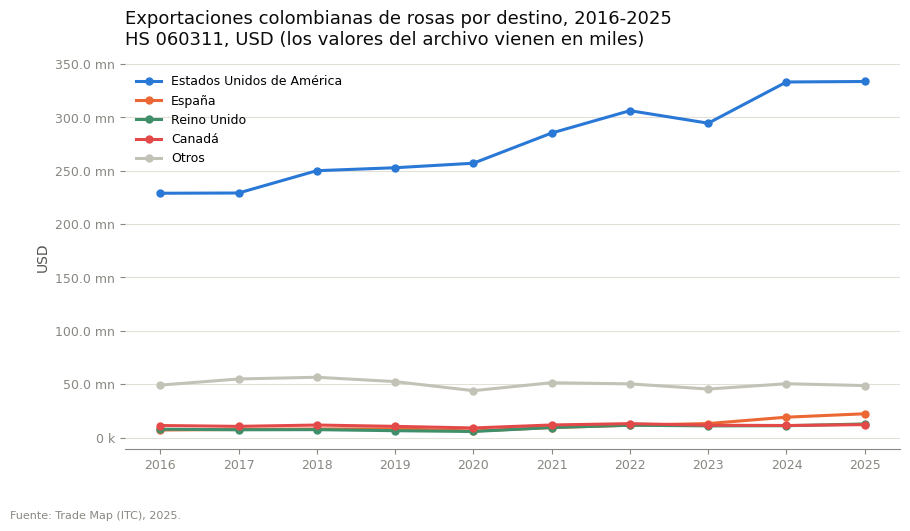

Figura guardada en salidas/g7_series_destinos.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
colores = CATEGORIAS + [GRIS_MID]
for color, columna in zip(colores, series_top.columns):
    ax.plot(series_top.index, series_top[columna], color=color, linewidth=2.2, marker="o", markersize=5, label=columna)
ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
ax.set_xticks(series_top.index)
ax.legend(frameon=False, fontsize=9, loc="upper left")
estilo(ax, "Exportaciones colombianas de rosas por destino, 2016-2025",
       "HS 060311, USD (los valores del archivo vienen en miles)", "Trade Map (ITC), 2025.", eje_y="USD")
guardar(fig, "g7_series_destinos")

In [10]:
# CAGR 2016-2025 y 2020-2025 por destino (los diez mayores de 2025)
ancho = paises_serie.pivot(index="pais", columns="anio", values="valor_kusd")
top10 = ancho[2025].nlargest(10).index
tabla_cagr = pd.DataFrame({
    "valor_2016": ancho.loc[top10, 2016],
    "valor_2025": ancho.loc[top10, 2025],
    "cagr_2016_2025_pct": [cagr(ancho.loc[p, 2016], ancho.loc[p, 2025], 9) for p in top10],
    "cagr_2020_2025_pct": [cagr(ancho.loc[p, 2020], ancho.loc[p, 2025], 5) for p in top10],
}).reset_index()
exportar(tabla_cagr, "g7_cagr_destinos")
tabla_cagr

,pais,valor_2016,valor_2025,cagr_2016_2025_pct,cagr_2020_2025_pct
0,Estados Unidos de América,228932,333643,4.2738,5.3530
1,España,7082,22287,13.5852,29.4929
2,Reino Unido,7822,12759,5.5871,17.5858
3,Canadá,11295,12121,0.7873,6.1658
4,Polonia,769,7319,28.4473,14.5863
5,Países Bajos,5843,6474,1.1460,-3.0103
6,"Corea, República de",310,4496,34.6020,30.9862
7,Brasil,3426,3321,-0.3453,23.1806
8,Kazajstán,660,2930,18.0116,14.6981
9,Rumania,603,2555,17.4018,13.7268


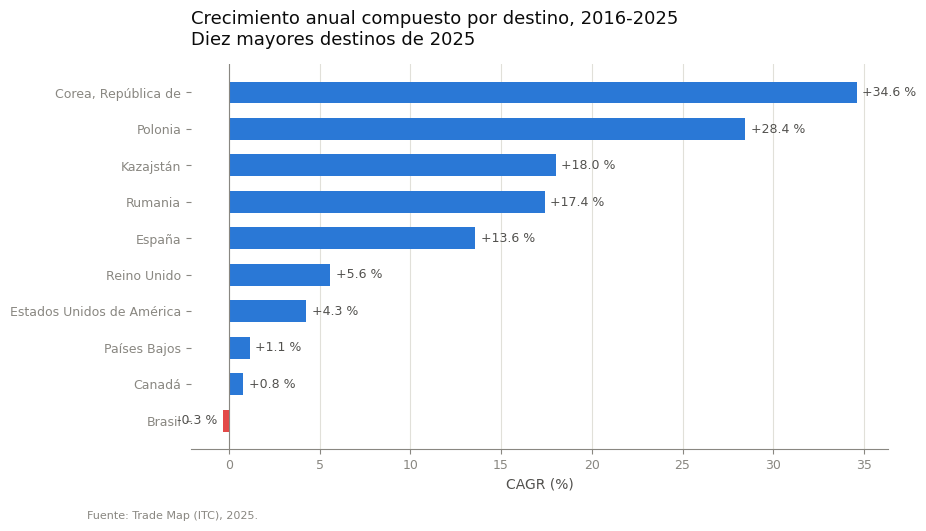

Figura guardada en salidas/g7_cagr_destinos.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
orden = tabla_cagr.sort_values("cagr_2016_2025_pct")
colores = [ROJO if v < 0 else AZUL for v in orden["cagr_2016_2025_pct"]]
ax.barh(orden["pais"], orden["cagr_2016_2025_pct"], color=colores, height=0.6)
for y, v in enumerate(orden["cagr_2016_2025_pct"]):
    ax.annotate(f"{v:+.1f} %", (v, y), textcoords="offset points", xytext=(4 if v >= 0 else -4, 0),
                ha="left" if v >= 0 else "right", va="center", fontsize=9, color=GRIS_TEXT)
ax.axvline(0, color=GRIS_EJE, linewidth=0.8)
estilo(ax, "Crecimiento anual compuesto por destino, 2016-2025",
       "Diez mayores destinos de 2025", "Trade Map (ITC), 2025.", eje_x="CAGR (%)", rejilla="x")
guardar(fig, "g7_cagr_destinos")

**Análisis del equipo:** ¿Qué destinos crecen, cuáles se estancan, y qué cambió después de 2020?

El análisis de la serie de tiempo de las exportaciones de rosas frescas colombianas de la última década revela patrones de comportamiento y tendencias críticas para la toma de decisiones del grupo:

Predominio absoluto y consolidación del mercado estadounidense:  
Estados Unidos se mantiene de manera consistente como el principal socio comercial. Las exportaciones pasaron de USD 228.9 millones en 2016 a USD 333.6 millones en 2025.  
Este mercado registra un crecimiento sostenido con una CAGR (2016-2025) del 4.27%, el cual se acelera a una CAGR del 5.35% en el periodo post-pandemia (2020-2025), demostrando una demanda madura pero altamente resiliente.

La revelación del mercado español (Crecimiento Exponencial):  
España se consolida como el segundo destino más importante y dinámico del portafolio. Pasó de recibir USD 7.0 millones en 2016 a USD 22.2 millones en 2025.  
Registra una impresionante CAGR de largo plazo (2016-2025) del 13.58%, disparándose a un vertiginoso 29.49% anual compuesto entre 2020 y 2025. Esto posiciona a España como un mercado de altísima prioridad para estrategias de penetración comercial agresiva.

Dinámicas del Reino Unido y Canadá:  
El Reino Unido muestra un comportamiento de recuperación acelerado. Aunque su crecimiento a largo plazo es moderado (CAGR 5.58%), su dinamismo reciente post-2020 es muy fuerte (CAGR 17.58%), impulsado probablemente por cambios en las cadenas de suministro post-Brexit.  
Canadá, por el contrario, se muestra como un mercado maduro y estancado en el largo plazo (CAGR 2016-2025 de apenas 0.78%), aunque su recuperación post-pandemia del 6.16% indica que aún conserva valor defensivo.

Mercados emergentes de alta velocidad:  
Se destacan los crecimientos extraordinarios en destinos menos tradicionales pero con alta capacidad adquisitiva, tales como Corea del Sur (CAGR 16-25 del 34.60%), Polonia (CAGR del 28.44%) y Kazajstán (CAGR del 18.01%). Estos destinos representan nichos de diversificación de alto valor unitario que reducen paulatinamente la vulnerabilidad de depender de un solo cliente geográfico.

**La decisión de negocio que habilita este análisis es implementar una estrategia de crecimiento selectivo y diversificación gradual de mercados, manteniendo a Estados Unidos como el principal mercado de defensa y generación de ingresos debido a su crecimiento sostenido y demanda resiliente, pero evitando aumentar la dependencia de este destino. En consecuencia, se debe asignar la mayor parte del capital comercial incremental a España, dado que combina una posición relevante dentro del portafolio con el mayor dinamismo reciente; desarrollar el Reino Unido como mercado secundario de expansión, aprovechando su recuperación posterior a 2020; conservar Canadá mediante una estrategia de mantenimiento y protección de clientes rentables, debido a su bajo crecimiento de largo plazo; y realizar inversiones piloto en Corea del Sur, Polonia y Kazajstán para validar su potencial como nichos de alto valor. Esta decisión permite aprovechar los mercados con mayor crecimiento sin poner en riesgo la base consolidada de Estados Unidos, mientras se construyen progresivamente nuevas fuentes de ingresos y se reduce la vulnerabilidad asociada a la concentración geográfica.**

***
# 3. Concentración de destinos: HHI, CR3 y número equivalente

In [12]:
concentracion = (paises_serie.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, CR3=lambda v: cr_n(v, 3), destinos_activos=lambda v: int((v > 0).sum()))
                 .reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
exportar(concentracion, "g7_hhi_destinos")
concentracion

,anio,HHI,CR3,destinos_activos,numero_equivalente
0,2016,0.5725,84.3744,68,1.7468
1,2017,0.5547,82.6603,77,1.8029
2,2018,0.5663,82.2962,78,1.7657
3,2019,0.5904,83.3993,76,1.6937
4,2020,0.6413,85.4761,77,1.5592
5,2021,0.6076,83.4576,69,1.6459
6,2022,0.6124,84.2529,68,1.6330
7,2023,0.6190,84.9845,76,1.6155
8,2024,0.6188,85.5322,77,1.6161
9,2025,0.6087,85.8396,78,1.6429


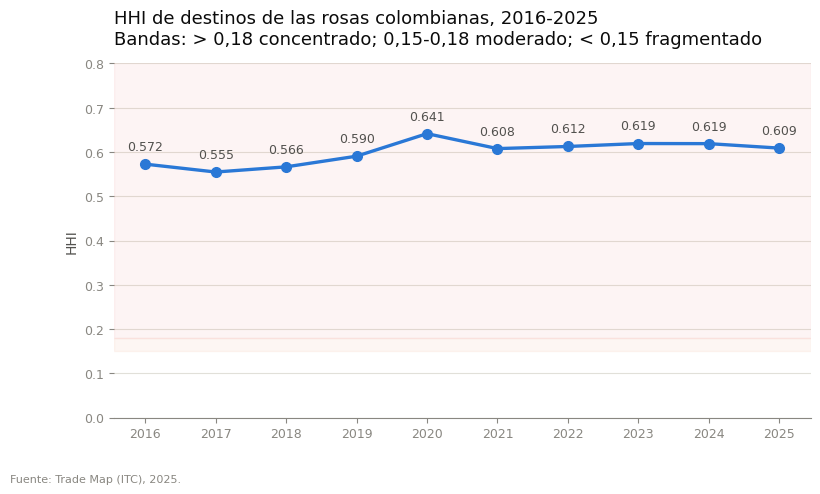

Figura guardada en salidas/g7_hhi_destinos.png


In [13]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(concentracion["anio"], concentracion["HHI"], color=AZUL, linewidth=2.4, marker="o", markersize=7)
for _, fila in concentracion.iterrows():
    ax.annotate(f"{fila['HHI']:.3f}", (fila["anio"], fila["HHI"]), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9, color=GRIS_TEXT)
ax.axhspan(0.18, 1, color=ROJO, alpha=0.06)
ax.axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
ax.set_ylim(0, max(0.8, concentracion["HHI"].max() * 1.15))
ax.set_xticks(concentracion["anio"])
estilo(ax, "HHI de destinos de las rosas colombianas, 2016-2025",
       "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", "Trade Map (ITC), 2025.", eje_y="HHI")
guardar(fig, "g7_hhi_destinos")

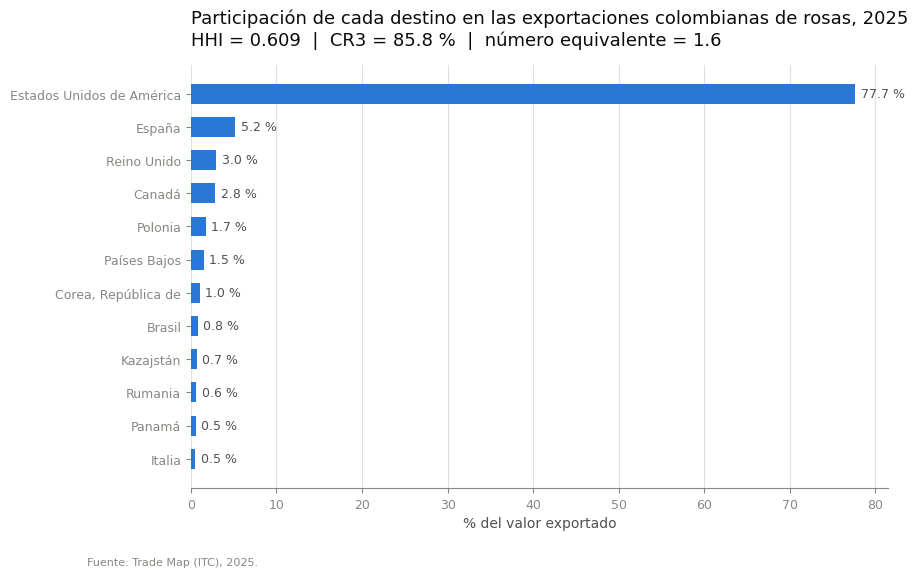

Figura guardada en salidas/g7_participacion_destinos_2025.png


In [14]:
# Participacion por destino en 2025
participacion = destinos_2025.nlargest(12, "valor_kusd")[["pais", "valor_kusd", "participacion_pct"]]
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = participacion.sort_values("participacion_pct")
ax.barh(orden["pais"], orden["participacion_pct"], color=AZUL, height=0.6)
for y, v in enumerate(orden["participacion_pct"]):
    ax.annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Participación de cada destino en las exportaciones colombianas de rosas, 2025",
       f"HHI = {concentracion.iloc[-1]['HHI']:.3f}  |  CR3 = {concentracion.iloc[-1]['CR3']:.1f} %  |  número equivalente = {concentracion.iloc[-1]['numero_equivalente']:.1f}",
       "Trade Map (ITC), 2025.", eje_x="% del valor exportado", rejilla="x")
guardar(fig, "g7_participacion_destinos_2025")

**Análisis del equipo:** ¿La concentración es un riesgo o una fortaleza para la Rosa Freedom? ¿Cambió la tendencia?

El análisis de los indicadores de concentración revela la estructura de riesgo y dependencia del sector exportador de rosas colombianas:

Nivel de Concentración Extremo y Estructura Duopolio/Monopolio de Hecho:  
El Índice de Herfindahl-Hirschman (HHI) se sitúa en 0.6087 para el año 2025. De acuerdo con los estándares internacionales de comercio, cualquier valor superior a 0.18 denota un mercado altamente concentrado.  
El indicador no solo es elevado, sino que muestra una tendencia al alza en los últimos 10 años (pasando de 0.5725 en 2016 a superar el 0.60 permanentemente a partir de 2020). Esto refleja que, lejos de diversificarse, la dependencia del portafolio exportador de Colombia se ha profundizado.

Concentración en los Tres Primeros Destinos (CR3):  
El CR3 alcanza el 85.83% en 2025. Esto significa que casi 86 de cada 100 dólares que Colombia recibe por exportar rosas provienen exclusivamente de tres países: Estados Unidos (77.68%), España (5.18%) y Reino Unido (2.97%).  
La dominancia es tan extrema que Estados Unidos por sí solo absorbe más de las tres cuartas partes del negocio.

Número Equivalente de Destinos:  
El número equivalente de mercados es de tan solo 1.6. A pesar de que Colombia registra exportaciones marginales a 78 destinos activos en 2025, la distribución real de las ventas equivale a operar en un escenario donde existieran únicamente 1.6 mercados de igual tamaño.

Implicación Estratégica (Riesgo vs. Fortaleza):  
Riesgo: Representa una vulnerabilidad macroeconómica crítica. Cualquier cambio regulatorio, fitosanitario, arancelario o recesión económica en los Estados Unidos afectaría de manera catastrófica e inmediata al empleo y los ingresos de la floricultura colombiana.  
Fortaleza/Oportunidad: Refleja una eficiencia operativa extraordinaria basada en una logística consolidada e integrada con el mercado norteamericano (especialmente para fechas clave como San Valentín y el Día de la Madre). No obstante, para la Rosa Freedom, priorizar canales alternos de crecimiento en mercados con cuotas menos saturadas pero dinámicas (como España y Reino Unido) es un imperativo para mitigar esta dependencia extrema.

La decisión de negocio que habilita este análisis es implementar un programa prioritario de diversificación geográfica que reduzca progresivamente la dependencia del mercado estadounidense, sin descuidar la eficiencia operativa y logística ya consolidada en dicho destino. El HHI de 0,6087, su tendencia creciente desde 2016 y el CR3 de 85,83 % evidencian una concentración extrema, mientras que el número equivalente de mercados de apenas 1,6 confirma que la presencia en 78 destinos no representa una diversificación efectiva de los ingresos. Por esta razón, la empresa debe mantener y proteger a Estados Unidos como principal fuente de volumen y rentabilidad, especialmente durante fechas comerciales clave, pero asignar capital comercial incremental a España y Reino Unido para aumentar su participación relativa y reducir la exposición a riesgos regulatorios, fitosanitarios, arancelarios o económicos concentrados en un solo país. La decisión también implica establecer metas cuantificables de desconcentración, como reducir el CR3 por debajo del 80 % en un horizonte de tres a cinco años y disminuir gradualmente el HHI, de manera que la expansión hacia nuevos destinos no se limite a aumentar el número de países atendidos, sino que genere una distribución más equilibrada y resistente de las exportaciones.

***
# 4. Balanza Comercial Relativa

In [15]:
mundo_imp_2025, _ = separar_mundo(imp_2025)
bcr_rosas = float(ibcr(mundo_2025["valor_kusd"], mundo_imp_2025["valor_kusd"]))

# La misma medida para el capitulo 06 completo (flores y plantas), 2021-2025, con la canasta del curso
x06, m06 = fila_canasta(canasta_co_exp, "06"), fila_canasta(canasta_co_imp, "06")
bcr_serie = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA], "X_cap06": x06.values, "M_cap06": m06.values})
bcr_serie["BCR_cap06"] = ibcr(bcr_serie["X_cap06"], bcr_serie["M_cap06"])

print(f"BCR rosas (HS 060311), 2025: X = {mundo_2025['valor_kusd']:,.0f}  M = {mundo_imp_2025['valor_kusd']:,.0f}  ->  BCR = {bcr_rosas:+.4f}")
exportar(bcr_serie, "g7_bcr")
bcr_serie

BCR rosas (HS 060311), 2025: X = 429,509  M = 265  ->  BCR = +0.9988


,anio,X_cap06,M_cap06,BCR_cap06
0,2021,"1,756,097.0000","61,121.0000",0.9327
1,2022,"2,082,840.0000","67,970.0000",0.9368
2,2023,"2,115,150.0000","70,669.0000",0.9353
3,2024,"2,385,846.0000","68,314.0000",0.9443
4,2025,"2,439,529.0000","76,043.0000",0.9395


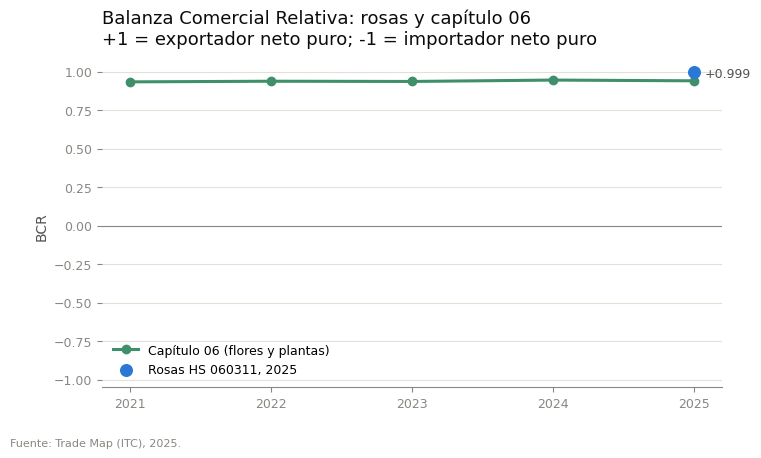

Figura guardada en salidas/g7_bcr.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(bcr_serie["anio"], bcr_serie["BCR_cap06"], color=VERDE, linewidth=2.2, marker="o", markersize=6, label="Capítulo 06 (flores y plantas)")
ax.scatter([2025], [bcr_rosas], color=AZUL, s=70, zorder=3, label="Rosas HS 060311, 2025")
ax.annotate(f"{bcr_rosas:+.3f}", (2025, bcr_rosas), textcoords="offset points", xytext=(8, -4), fontsize=9, color=GRIS_TEXT)
ax.set_ylim(-1.05, 1.05)
ax.axhline(0, color=GRIS_EJE, linewidth=0.8)
ax.set_xticks(bcr_serie["anio"])
ax.legend(frameon=False, fontsize=9, loc="lower left")
estilo(ax, "Balanza Comercial Relativa: rosas y capítulo 06", "+1 = exportador neto puro; -1 = importador neto puro",
       "Trade Map (ITC), 2025.", eje_y="BCR")
guardar(fig, "g7_bcr")

**Análisis del equipo:**

Balanza Comercial Relativa (BCR)  
El comportamiento de la Balanza Comercial Relativa (BCR) consolida el diagnóstico de la especialización de la balanza comercial floricultora de Colombia:

Exportador Neto Puro de Rosas:  
El índice BCR para las rosas frescas (HS 060311) en 2025 se ubica en un casi absoluto +0.9988.  
Esto es el resultado de registrar exportaciones récord por USD 429.5 millones frente a importaciones insignificantes de apenas USD 265 mil (provenientes casi en su totalidad de Ecuador para cubrir demandas muy puntuales o temporales).  
Este valor cercano a +1.00 confirma que Colombia posee un superávit comercial absoluto y es un oferente neto puro de este producto en el mercado global.

Comportamiento Sectorial Estable (Capítulo 06):  
Al ampliar la perspectiva al Capítulo 06 de la canasta comercial (que agrupa a todas las flores, plantas vivas y follajes), la BCR mantiene una estabilidad impecable a lo largo del quinquenio 2021-2025, oscilando siempre de forma robusta entre +0.93 y +0.94.  
El sector floricultor colombiano en su conjunto muestra una estructura fuertemente orientada a la exportación, donde las necesidades de importación de material vegetal son mínimas frente al gigantesco volumen exportado (que en 2025 superó los USD 2,439 millones).

**La decisión de negocio que habilita este análisis es consolidar y ampliar la estrategia exportadora de la floricultura colombiana, aprovechando la ventaja competitiva demostrada por el sector, pero orientando el crecimiento hacia una mayor diversificación de mercados y clientes. La Balanza Comercial Relativa de las rosas frescas, con un valor de +0,9988 en 2025, confirma que Colombia es un exportador neto prácticamente puro, al registrar exportaciones por USD 429,5 millones frente a importaciones marginales de USD 265 mil; por su parte, la estabilidad de la BCR del Capítulo 06, entre +0,93 y +0,94 durante 2021-2025, demuestra que esta especialización no es circunstancial, sino una fortaleza estructural del sector floricultor. En consecuencia, la empresa debe priorizar inversiones destinadas a aumentar la capacidad exportadora, preservar la productividad, fortalecer la calidad, la logística y el cumplimiento fitosanitario, y aprovechar la baja dependencia de insumos importados como soporte de su competitividad. Sin embargo, esta decisión no debe traducirse únicamente en vender más a los mercados actuales, sino en utilizar el superávit y la especialización existentes para expandirse hacia nuevos destinos y reducir la vulnerabilidad asociada a la concentración geográfica, manteniendo al mismo tiempo la actividad floricultora como eje central del crecimiento.**

***
# 5. Participación de mercado en cada destino

La columna `cuota_en_socio_pct` de Trade Map es exactamente la definición de la ficha: exportaciones de Colombia al destino sobre las importaciones totales de rosas de ese destino.

In [17]:
mercados = destinos_2025.nlargest(15, "valor_kusd")[
    ["pais", "valor_kusd", "cuota_en_socio_pct", "ranking_socio", "crec_valor_5a_pct", "crec_importaciones_socio_5a_pct", "valor_unitario"]]
exportar(mercados, "g7_participacion_mercado")
mercados

,pais,valor_kusd,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_importaciones_socio_5a_pct,valor_unitario
0,Estados Unidos de América,333643,56.2147,1.0000,4.0000,8.0000,"7,044.9800"
1,España,22287,37.5607,9.0000,25.0000,12.0000,"6,362.2600"
2,Reino Unido,12759,6.9467,4.0000,6.0000,4.0000,"6,067.0500"
3,Canadá,12121,53.0240,10.0000,-1.0000,3.0000,"7,514.5700"
4,Polonia,7319,3.1061,7.0000,9.0000,8.0000,"8,432.0300"
5,Países Bajos,6474,1.5702,2.0000,-8.0000,3.0000,"8,966.7600"
6,"Corea, República de",4496,62.5907,34.0000,24.0000,22.0000,"6,279.3300"
7,Brasil,3321,62.9948,51.0000,35.0000,35.0000,"8,559.2800"
8,Kazajstán,2930,3.9432,14.0000,14.0000,19.0000,"7,940.3800"
9,Rumania,2555,NaN,15.0000,0.0000,14.0000,"5,860.0900"


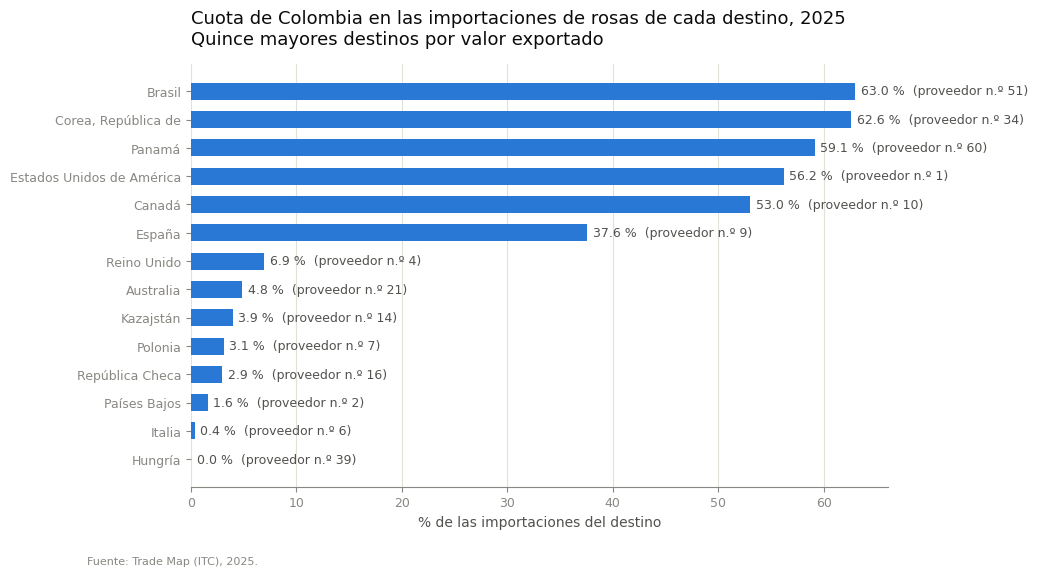

Figura guardada en salidas/g7_cuota_en_destino.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = mercados.dropna(subset=["cuota_en_socio_pct"]).sort_values("cuota_en_socio_pct")
ax.barh(orden["pais"], orden["cuota_en_socio_pct"], color=AZUL, height=0.6)
for y, (v, r) in enumerate(zip(orden["cuota_en_socio_pct"], orden["ranking_socio"])):
    ax.annotate(f"{v:.1f} %  (proveedor n.º {r:.0f})", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Cuota de Colombia en las importaciones de rosas de cada destino, 2025",
       "Quince mayores destinos por valor exportado", "Trade Map (ITC), 2025.", eje_x="% de las importaciones del destino", rejilla="x")
guardar(fig, "g7_cuota_en_destino")

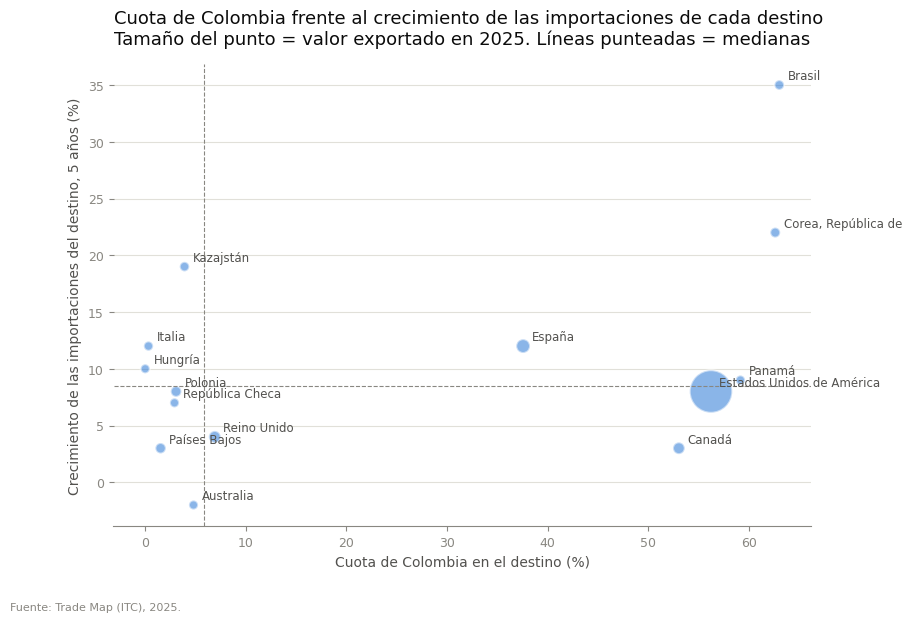

Figura guardada en salidas/g7_cuota_vs_crecimiento.png


In [19]:
# Cuota actual frente a crecimiento de la demanda del destino (importaciones totales de rosas del socio, 5 anios)
fig, ax = plt.subplots(figsize=(9, 6))
puntos = mercados.dropna(subset=["cuota_en_socio_pct", "crec_importaciones_socio_5a_pct"])
tamanos = puntos["valor_kusd"] / puntos["valor_kusd"].max() * 900 + 40
ax.scatter(puntos["cuota_en_socio_pct"], puntos["crec_importaciones_socio_5a_pct"], s=tamanos, color=AZUL, alpha=0.55, edgecolor="white", linewidth=1.5)
for _, p in puntos.iterrows():
    ax.annotate(p["pais"], (p["cuota_en_socio_pct"], p["crec_importaciones_socio_5a_pct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5, color=GRIS_TEXT)
ax.axhline(puntos["crec_importaciones_socio_5a_pct"].median(), color=GRIS_EJE, linewidth=0.8, linestyle="--")
ax.axvline(puntos["cuota_en_socio_pct"].median(), color=GRIS_EJE, linewidth=0.8, linestyle="--")
estilo(ax, "Cuota de Colombia frente al crecimiento de las importaciones de cada destino",
       "Tamaño del punto = valor exportado en 2025. Líneas punteadas = medianas", "Trade Map (ITC), 2025.",
       eje_x="Cuota de Colombia en el destino (%)", eje_y="Crecimiento de las importaciones del destino, 5 años (%)")
guardar(fig, "g7_cuota_vs_crecimiento")

**Análisis del equipo:** ¿En qué cuadrante cae cada mercado candidato (Estados Unidos, Canadá, Reino Unido, Países Bajos, Japón)?

Esta gráfica permite identificar cuáles son los mercados más atractivos para Colombia teniendo en cuenta dos factores: la participación que ya tiene Colombia y el crecimiento de las importaciones de cada destino.  
Los mercados ubicados en la parte superior derecha tienen una cuota alta y un crecimiento alto, por lo que son mercados “A Crecer”. Los de la parte inferior derecha tienen una cuota alta, pero un crecimiento bajo, por lo que la estrategia sería “Defender”. En la parte superior izquierda están los mercados con baja cuota pero alto crecimiento, considerados mercados para “Pilotear”, mientras que los de la parte inferior izquierda presentan baja cuota y bajo crecimiento, por lo que se deben “Monitorear”.  
Para Colombia, Estados Unidos y Canadá destacan por combinar una buena participación con un crecimiento importante, además de representar un volumen significativo de exportaciones. Por otro lado, Reino Unido, Países Bajos y Japón pueden requerir estrategias diferentes dependiendo de su posición exacta en la gráfica.

Decisión de negocio:   La decisión sería priorizar Estados Unidos y Canadá para aumentar las exportaciones y fortalecer la presencia de Colombia, debido a que combinan participación y crecimiento. En los demás mercados, se deberían aplicar estrategias diferentes según su posición: defender donde ya existe una buena participación, pilotear donde haya crecimiento pero poca presencia y monitorear aquellos con menor atractivo.

***
# 6. Valor unitario

Como advierte la ficha, el valor unitario **no equivale a margen ni a precio neto**: es valor FOB dividido por toneladas.

In [20]:
# Colombia frente a los grandes exportadores (se excluyen los que no reportan cantidad)
competidores = exportadores.nlargest(10, "valor_kusd")
competidores = competidores[(competidores["cantidad"] > 0) & competidores["valor_unitario"].notna()]
competidores = competidores[["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_mundial_pct"]]
exportar(competidores, "g7_valor_unitario_competidores")
competidores

,pais,valor_kusd,cantidad,valor_unitario,participacion_mundial_pct
0,Países Bajos,"1,534,472.0000","422,364.0000","3,633.0600",40.0542
1,Ecuador,"791,211.0000","145,227.0000","5,448.1000",20.6529
2,Kenya,"552,168.0000","126,990.0000","4,348.1200",14.4132
3,Colombia,"429,509.0000","61,015.0000","7,039.4000",11.2114
5,China,"64,338.0000","18,258.0000","3,523.8300",1.6794
6,España,"35,703.0000","3,501.0000","10,197.9400",0.9320
7,Armenia,"27,729.0000","6,473.0000","4,283.7900",0.7238
8,Guatemala,"24,793.0000","10,438.0000","2,375.2600",0.6472
9,Alemania,"20,095.0000","2,049.0000","9,807.2200",0.5245


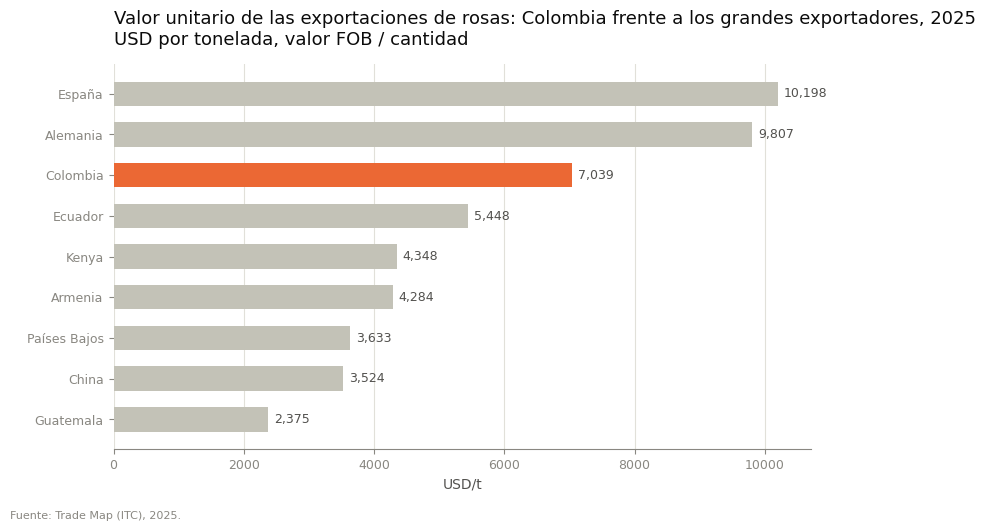

Figura guardada en salidas/g7_valor_unitario_competidores.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
orden = competidores.sort_values("valor_unitario")
colores = [NARANJA if p == "Colombia" else GRIS_MID for p in orden["pais"]]
ax.barh(orden["pais"], orden["valor_unitario"], color=colores, height=0.6)
for y, v in enumerate(orden["valor_unitario"]):
    ax.annotate(f"{v:,.0f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Valor unitario de las exportaciones de rosas: Colombia frente a los grandes exportadores, 2025",
       "USD por tonelada, valor FOB / cantidad", "Trade Map (ITC), 2025.", eje_x="USD/t", rejilla="x")
guardar(fig, "g7_valor_unitario_competidores")

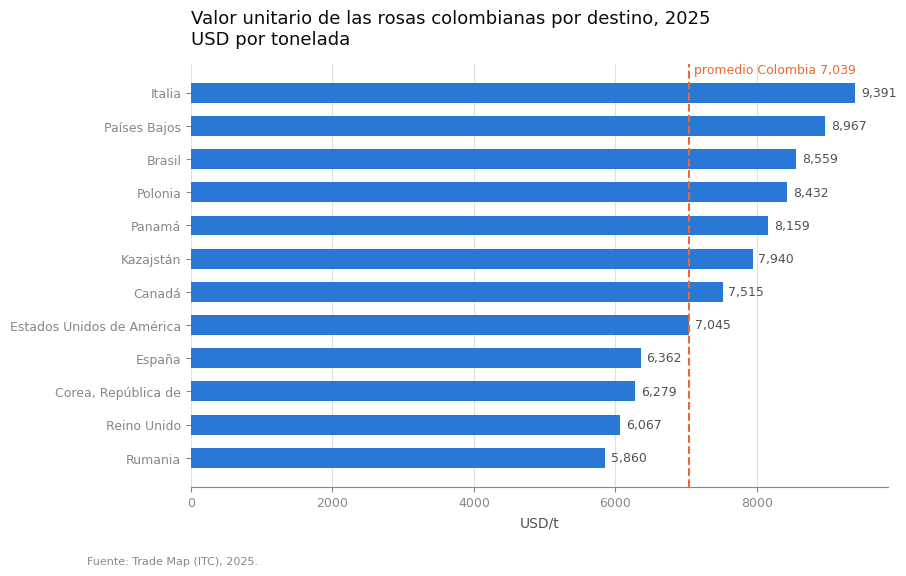

Figura guardada en salidas/g7_valor_unitario_destinos.png


,pais,valor_kusd,cantidad,valor_unitario
0,Estados Unidos de América,333643,"47,359.0000","7,044.9800"
1,España,22287,"3,503.0000","6,362.2600"
2,Reino Unido,12759,"2,103.0000","6,067.0500"
3,Canadá,12121,"1,613.0000","7,514.5700"
4,Polonia,7319,868.0000,"8,432.0300"
5,Países Bajos,6474,722.0000,"8,966.7600"
6,"Corea, República de",4496,716.0000,"6,279.3300"
7,Brasil,3321,388.0000,"8,559.2800"
8,Kazajstán,2930,369.0000,"7,940.3800"
9,Rumania,2555,436.0000,"5,860.0900"


In [22]:
# Valor unitario por destino de Colombia
vu_destinos = destinos_2025.nlargest(12, "valor_kusd")
vu_destinos = vu_destinos[vu_destinos["cantidad"] > 0][["pais", "valor_kusd", "cantidad", "valor_unitario"]]
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = vu_destinos.sort_values("valor_unitario")
ax.barh(orden["pais"], orden["valor_unitario"], color=AZUL, height=0.6)
ax.axvline(mundo_2025["valor_unitario"], color=NARANJA, linewidth=1.5, linestyle="--")
ax.annotate(f"promedio Colombia {mundo_2025['valor_unitario']:,.0f}", (mundo_2025["valor_unitario"], len(orden) - 0.4),
            fontsize=9, color=NARANJA, ha="left", xytext=(4, 0), textcoords="offset points")
for y, v in enumerate(orden["valor_unitario"]):
    ax.annotate(f"{v:,.0f}", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Valor unitario de las rosas colombianas por destino, 2025", "USD por tonelada",
       "Trade Map (ITC), 2025.", eje_x="USD/t", rejilla="x")
guardar(fig, "g7_valor_unitario_destinos")
exportar(vu_destinos, "g7_valor_unitario_destinos")

**Análisis del equipo:**

En esta metrica se permite conocer a qué precio vende Colombia sus rosas frente a otros grandes exportadores y cuánto obtiene por sus rosas en diferentes destinos.  
El valor unitario, expresado en dólares por tonelada, sirve como referencia para entender el posicionamiento del producto. Un valor unitario más alto puede estar relacionado con factores como calidad, características del producto, presentación o condiciones del mercado, mientras que un valor más bajo puede estar relacionado con una estrategia de mayor volumen o con segmentos de precios más bajos.  
Al comparar a Colombia con otros grandes exportadores, podemos identificar si las rosas colombianas tienen un posicionamiento de mayor o menor valor. Además, al analizar los diferentes destinos, se puede observar en qué mercados Colombia obtiene un mayor valor por cada tonelada exportada.  
Esto es especialmente importante para la Rosa Freedom, porque permite identificar mercados donde los compradores están dispuestos a pagar un mayor valor y, por lo tanto, donde podría existir una oportunidad para fortalecer un posicionamiento de calidad y mayor valor agregado.

Decisión de negocio:   La decisión sería priorizar los destinos donde Colombia obtiene un mayor valor por tonelada, buscando posicionar la Rosa Freedom como un producto de calidad y no únicamente competir por precio. En los mercados donde el valor unitario sea menor, se podría analizar cómo mejorar la presentación, diferenciación o estrategia comercial para aumentar el valor obtenido.



***
# 7. Cuota en la oferta mundial

HHI de la oferta mundial de rosas, 2025: 0.2418  (número equivalente de exportadores: 4.1)


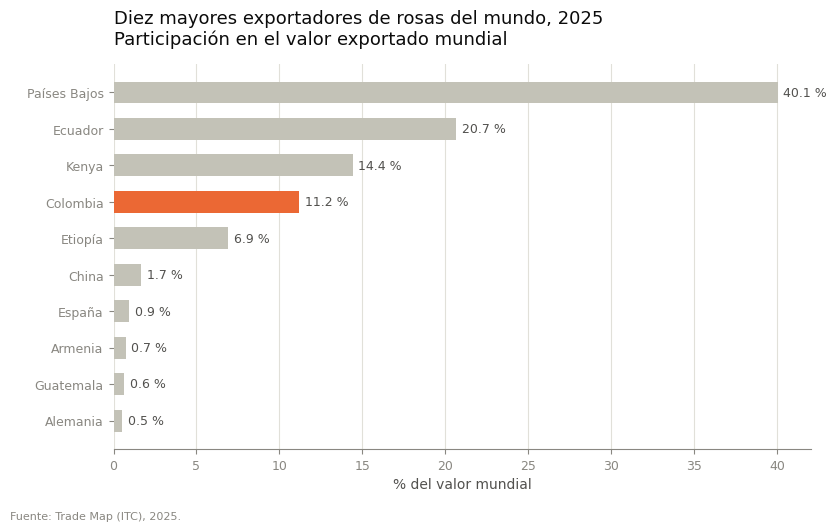

Figura guardada en salidas/g7_oferta_mundial.png


,pais,valor_kusd,participacion_mundial_pct,crec_valor_5a_pct
0,Países Bajos,"1,534,472.0000",40.0542,0.0000
1,Ecuador,"791,211.0000",20.6529,4.0000
2,Kenya,"552,168.0000",14.4132,1.0000
3,Colombia,"429,509.0000",11.2114,4.0000
4,Etiopía,"265,016.0000",6.9177,2.0000
5,China,"64,338.0000",1.6794,41.0000
6,España,"35,703.0000",0.9320,34.0000
7,Armenia,"27,729.0000",0.7238,44.0000
8,Guatemala,"24,793.0000",0.6472,10.0000
9,Alemania,"20,095.0000",0.5245,-3.0000


In [23]:
oferta = exportadores.nlargest(10, "valor_kusd")[["pais", "valor_kusd", "participacion_mundial_pct", "crec_valor_5a_pct"]]
hhi_oferta = hhi(exportadores["valor_kusd"])
print(f"HHI de la oferta mundial de rosas, 2025: {hhi_oferta:.4f}  (número equivalente de exportadores: {numeros_equivalentes(hhi_oferta):.1f})")
fig, ax = plt.subplots(figsize=(9, 5))
orden = oferta.sort_values("participacion_mundial_pct")
colores = [NARANJA if p == "Colombia" else GRIS_MID for p in orden["pais"]]
ax.barh(orden["pais"], orden["participacion_mundial_pct"], color=colores, height=0.6)
for y, v in enumerate(orden["participacion_mundial_pct"]):
    ax.annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
estilo(ax, "Diez mayores exportadores de rosas del mundo, 2025", "Participación en el valor exportado mundial",
       "Trade Map (ITC), 2025.", eje_x="% del valor mundial", rejilla="x")
guardar(fig, "g7_oferta_mundial")
exportar(oferta, "g7_oferta_mundial")

**Análisis del equipo:**

Este analisis de datos nos muestra a los diez mayores exportadores de rosas del mundo, permitiendo conocer quiénes son los principales competidores de Colombia y qué participación tiene cada país en el mercado mundial.  
Además, el Índice de Herfindahl-Hirschman (HHI) permite determinar qué tan concentrado está el mercado. Un HHI alto significa que una cantidad reducida de países concentra gran parte de las exportaciones, mientras que un HHI bajo indica que el mercado está más distribuido entre diferentes exportadores.  
También se utiliza el número equivalente de exportadores (1/HHI), que ayuda a interpretar la concentración del mercado en términos del número de competidores de igual tamaño que representarían esa misma estructura.

Este análisis permite entender si Colombia está compitiendo en un mercado dominado por pocos países o en uno donde existe mayor diversidad de competidores. También ayuda a identificar los principales referentes frente a los cuales Colombia debe diferenciarse y fortalecer sus ventajas competitivas.

Decisión de negocio:La decisión sería fortalecer la diferenciación de las rosas colombianas frente a los principales competidores, especialmente mediante calidad, confiabilidad, presentación y valor agregado. Si el mercado está concentrado, Colombia debería enfocarse en consolidar sus mercados actuales y diferenciarse para ganar participación; si está más fragmentado, tendría mayores posibilidades de buscar nuevos mercados y aumentar su cuota.



***
# 8. Ventaja comparativa revelada: RCA de Balassa, RSCA y NRCA

El numerador sale de las descargas del equipo; el denominador mundial (exportaciones totales de todos los productos) sale de la canasta del curso `mundo_exp_productos_hs2_serie.csv`, fila TOTAL.

In [24]:
X_ij = mundo_2025["valor_kusd"]                                   # Colombia exporta rosas, 2025
X_i  = separar_mundo(exp_all)[0]["valor_kusd"]                    # Colombia exporta todo, 2025
X_j  = mundo_oferta["valor_kusd"]                                  # el mundo exporta rosas, 2025
X_w  = fila_canasta(canasta_mundo_exp, "TOTAL")["2025"]            # el mundo exporta todo, 2025

vcr = pd.DataFrame({
    "indice": ["RCA (Balassa)", "RSCA (Laursen)", "NRCA (Yu, Cai y Leung) x 10^4"],
    "valor": [float(rca_balassa(X_ij, X_i, X_j, X_w)),
              float(rsca_laursen(rca_balassa(X_ij, X_i, X_j, X_w))),
              float(nrca(X_ij, X_i, X_j, X_w)) * 1e4],
    "umbral_neutral": [1, 0, 0],
})
print(f"X_ij = {X_ij:,.0f}   X_i = {X_i:,.0f}   X_j = {X_j:,.0f}   X_w = {X_w:,.0f}   (USD miles)")
exportar(vcr, "g7_vcr_2025")
vcr

X_ij = 429,509   X_i = 50,172,751   X_j = 3,830,991   X_w = 25,609,329,378   (USD miles)


,indice,valor,umbral_neutral
0,RCA (Balassa),57.2257,1
1,RSCA (Laursen),0.9657,0
2,"NRCA (Yu, Cai y Leung) x 10^4",0.1648,0


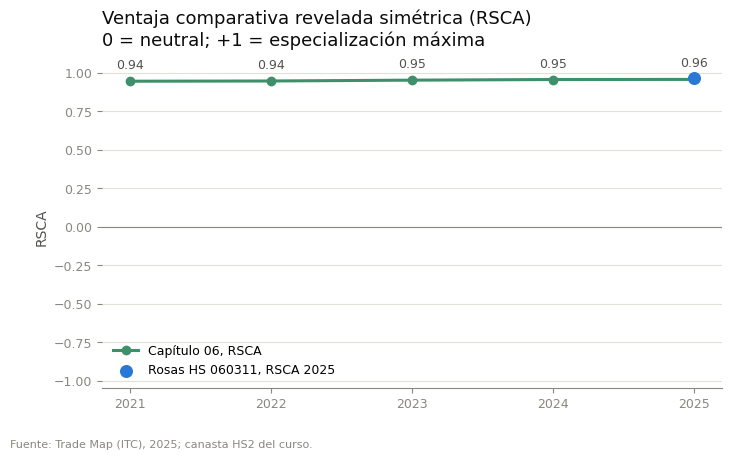

Figura guardada en salidas/g7_rsca.png


,anio,RCA_cap06,RSCA_cap06
0,2021,34.3259,0.9434
1,2022,35.2803,0.9449
2,2023,39.2467,0.9503
3,2024,42.8803,0.9544
4,2025,43.5725,0.9551


In [25]:
# La misma familia para el capitulo 06 completo, 2021-2025, con la canasta del curso
vcr_serie = pd.DataFrame({"anio": [int(a) for a in ANIOS_CANASTA]})
vcr_serie["RCA_cap06"] = rca_balassa(fila_canasta(canasta_co_exp, "06"), fila_canasta(canasta_co_exp, "TOTAL"),
                                     fila_canasta(canasta_mundo_exp, "06"), fila_canasta(canasta_mundo_exp, "TOTAL"))
vcr_serie["RSCA_cap06"] = rsca_laursen(vcr_serie["RCA_cap06"])
exportar(vcr_serie, "g7_vcr_serie_cap06")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(vcr_serie["anio"], vcr_serie["RSCA_cap06"], color=VERDE, linewidth=2.2, marker="o", markersize=6, label="Capítulo 06, RSCA")
ax.scatter([2025], [vcr.loc[1, "valor"]], color=AZUL, s=70, zorder=3, label="Rosas HS 060311, RSCA 2025")
for _, fila in vcr_serie.iterrows():
    ax.annotate(f"{fila['RSCA_cap06']:.2f}", (fila["anio"], fila["RSCA_cap06"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
ax.set_ylim(-1.05, 1.05)
ax.axhline(0, color=GRIS_EJE, linewidth=0.8)
ax.set_xticks(vcr_serie["anio"])
ax.legend(frameon=False, fontsize=9, loc="lower left")
estilo(ax, "Ventaja comparativa revelada simétrica (RSCA)", "0 = neutral; +1 = especialización máxima",
       "Trade Map (ITC), 2025; canasta HS2 del curso.", eje_y="RSCA")
guardar(fig, "g7_rsca")
vcr_serie

**Análisis del equipo:** ¿La ventaja es de las rosas en particular o del sector floricultor completo?

Lo que muestra la gráfica

Entre 2021 y 2025, tanto el Capítulo 06 completo (plantas vivas y productos de floricultura) como la subpartida de rosas frescas (HS 060311) presentan RSCA sistemáticamente cercanos al techo teórico de +1. El RSCA del capítulo pasó de 0,9434 a 0,9551, mientras que el RCA de Balassa subyacente se multiplicó de 34,3 a 43,6 veces la participación esperada bajo comercio neutral (International Trade Centre [ITC], 2025). En 2025, la subpartida de rosas registra un RSCA de 0,96, apenas 0,005 puntos por encima del promedio del capítulo ese mismo año.

¿La ventaja es de las rosas o del sector completo?

La evidencia apunta a una ventaja sectorial, con la rosa como su expresión más concentrada, no como un fenómeno aislado del producto:

Las dos series casi no se separan. Si la especialización dependiera solo de la rosa, cabría esperar una brecha amplia frente al capítulo, que agrega claveles, crisantemos, hortensias y astromelias, entre otras especies. En cambio, ambas curvas se mueven pegadas al techo del indicador, señal de que todo el sector floricultor —no un único producto— está altamente especializado.  
El peso de la rosa explica el arrastre del promedio, no lo sustituye. Las rosas frescas concentran la mayor proporción del valor FOB dentro de la matriz exportadora floricultora, con una participación superior al 62 %, seguidas por crisantemos y pompones (DataSur, 2026). Eso explica por qué su desempeño hala el promedio del capítulo hacia arriba, pero no implica que el resto del sector sea débil: Colombia es el segundo mayor exportador mundial de flores de corte, con más de 1.600 variedades comercializadas y cerca de 240.000 empleos directos e indirectos ligados a toda la cadena, no solo a la rosa (Semana, 2026).  
El origen de la ventaja es estructural, no exclusivo de una especie. La especialización colombiana responde a condiciones geográficas transversales: la altitud y el fotoperiodo estable de la Sabana de Bogotá y el oriente antioqueño (temperaturas entre 13 °C y 21 °C, sin estaciones marcadas, que permiten varias cosechas al año), sumados a costos de tierra y mano de obra históricamente bajos frente a Estados Unidos y una cercanía logística estratégica a ese mercado, que absorbe cerca del 80 % del valor exportado (Cámara de Comercio de Bogotá, 2015; La República, 2026). Estas condiciones benefician por igual a rosas, claveles y crisantemos; la rosa simplemente las capitaliza con mayor intensidad por sus atributos de tallo largo y vida en florero, muy valorados en fechas pico como San Valentín y el Día de la Madre.

Qué decisión habilita

Para una empresa exportadora de la variedad Freedom, esto significa que su ventaja no descansa en una moda de producto ni en un nicho frágil, sino en una base sectorial estable y creciente durante al menos cinco años. Eso respalda decisiones de mediano plazo —expansión de área sembrada, contratos de suministro a más de un año, certificaciones de calidad— con bajo riesgo de que la ventaja país se erosione. El verdadero reto competitivo no está en la ventaja país, que ya es sólida, sino en la disputa por margen dentro de un sector concentrado: los diez principales exportadores de flores ya acaparan más del 40 % del valor FOB despachado (DataSur, 2026), por lo que la diferenciación por variedad, calidad y trazabilidad será decisiva para capturar valor dentro de una ventaja que, en sí misma, ya está prácticamente garantizada.



***
# 9. Índice de Lafay

In [26]:
# (a) Las rosas dentro del comercio total de Colombia, 2025
M_ij = mundo_imp_2025["valor_kusd"]
M_i  = separar_mundo(imp_all)[0]["valor_kusd"]
ibcr_rosas = (X_ij - M_ij) / (X_ij + M_ij)
ibcr_pais  = (X_i - M_i) / (X_i + M_i)
peso_rosas = (X_ij + M_ij) / (X_i + M_i)
lfi_rosas  = 100 * (ibcr_rosas - ibcr_pais) * peso_rosas
print(f"Lafay rosas 2025: IBCR producto = {ibcr_rosas:+.4f} | IBCR pais = {ibcr_pais:+.4f} | peso = {peso_rosas:.4%} | LFI = {lfi_rosas:+.4f}")

# (b) Lafay de los 97 capitulos de la canasta, 2025, para ubicar el capitulo 06 en contexto
capitulos = canasta_co_exp[canasta_co_exp["codigo"] != "TOTAL"][["codigo", "producto", "2025"]].rename(columns={"2025": "X"})
capitulos = capitulos.merge(canasta_co_imp[["codigo", "2025"]].rename(columns={"2025": "M"}), on="codigo", how="inner")
capitulos["LFI"] = lafay(capitulos["X"], capitulos["M"])
capitulos["producto"] = capitulos["producto"].str.slice(0, 45)
ranking_lafay = capitulos.sort_values("LFI", ascending=False).reset_index(drop=True)
exportar(ranking_lafay, "g7_lafay_capitulos")
ranking_lafay.head(10)

Lafay rosas 2025: IBCR producto = +0.9988 | IBCR pais = -0.1685 | peso = 0.3561% | LFI = +0.4157


,codigo,producto,X,M,LFI
0,27,"Mineral fuels, mineral oils and products of t",17493450,5796487,12.9443
1,09,"Coffee, tea, maté and spices",5981026,393683,5.5200
2,71,"Natural or cultured pearls, precious or semi-",4854760,127772,4.6127
3,06,"Live trees and other plants; bulbs, roots and",2439529,76043,2.3097
4,08,Edible fruit and nuts; peel of citrus fruit o,2193307,385552,1.8581
5,26,"Ores, slag and ash",957087,19166,0.9135
6,15,"Animal, vegetable or microbial fats and oils",1284519,877219,0.6393
7,17,Sugars and sugar confectionery,730474,195570,0.5725
8,76,Aluminium and articles thereof,895795,678662,0.3997
9,18,Cocoa and cocoa preparations,413182,113224,0.3221


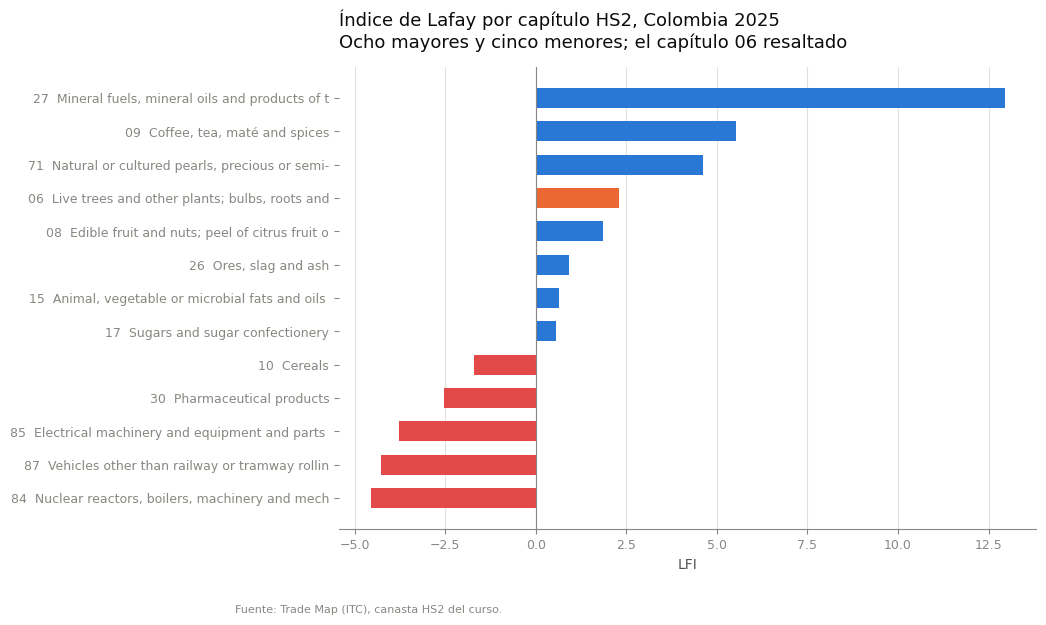

Figura guardada en salidas/g7_lafay_capitulos.png


In [27]:
extremos = pd.concat([ranking_lafay.head(8), ranking_lafay.tail(5)]).sort_values("LFI")
fig, ax = plt.subplots(figsize=(9, 6))
colores = [NARANJA if c == "06" else (AZUL if v >= 0 else ROJO) for c, v in zip(extremos["codigo"], extremos["LFI"])]
ax.barh(extremos["codigo"] + "  " + extremos["producto"], extremos["LFI"], color=colores, height=0.6)
ax.axvline(0, color=GRIS_EJE, linewidth=0.8)
estilo(ax, "Índice de Lafay por capítulo HS2, Colombia 2025", "Ocho mayores y cinco menores; el capítulo 06 resaltado",
       "Trade Map (ITC), canasta HS2 del curso.", eje_x="LFI", rejilla="x")
guardar(fig, "g7_lafay_capitulos")

**Análisis del equipo:**

El capítulo 27 (combustibles) lidera con un LFI cercano a 12,7, seguido por el 09 (café, ~5,3) y el 71 (perlas y metales preciosos, ~4,7). El capítulo 06 (floricultura, donde están las rosas) ocupa el cuarto lugar, con un LFI de aproximadamente 2,2–2,4 —positivo, pero equivalente a menos de una sexta parte del aporte del petróleo—. En el extremo negativo, maquinaria, vehículos, farmacéuticos y cereales confirman que Colombia es importador neto estructural de bienes de capital y tecnología.

Qué significa para el caso

Para la pregunta central del proyecto —qué mercados de destino ofrecen la mejor combinación de ventaja comparativa, participación, crecimiento de demanda y riesgo controlable para la Rosa Freedom— este indicador no da un dato por país de destino (eso vendrá de los indicadores de participación y crecimiento por mercado), pero sí aporta una pieza de contexto que condiciona cómo leer esos datos: qué tan "sistémico" es el sector floricultor para Colombia frente a otros sectores exportadores. Un LFI positivo pero moderado significa que las flores son una ventaja genuina y consolidada, pero no un sector que determine la política cambiaria o comercial del país como sí lo hace el petróleo o, en menor medida, el café. En la práctica: la empresa no puede asumir que el Estado ajustará el tipo de cambio o intervendrá comercialmente para proteger la competitividad de las rosas ante un shock —esa prioridad de política pública está reservada a los sectores de mayor peso—. El riesgo cambiario y comercial de exportar Rosa Freedom depende entonces, en buena medida, de decisiones que la propia empresa debe tomar mercado por mercado, no de un respaldo macro garantizado.

Qué decisión habilita

Concretamente, una empresa hipotética que exporte Rosa Freedom usaría este hallazgo así: al saber que el "colchón" de política pública alrededor de las flores es limitado frente al de sectores como el petrolero, trataría el criterio de "riesgo controlable" del caso como una variable que ella misma debe gestionar activamente por mercado, priorizando los destinos donde ese riesgo sea más fácil de cubrir. Esto la llevaría a mantener a Estados Unidos como mercado ancla —no solo por su participación ya dominante (cerca del 80 % del valor exportado, según Asocolflores), sino porque el dólar es la divisa más líquida y económica de cubrir con instrumentos financieros estándar (forwards, opciones)—, mientras destina una porción acotada y creciente del portafolio a mercados donde el riesgo cambiario es mayor pero aún manejable, como el Reino Unido (US$34,4 millones FOB) o Canadá (US$23,9 millones FOB), y trataría con más cautela mercados lejanos como Japón (US$14,5 millones FOB), donde el riesgo fitosanitario y logístico —no solo el cambiario— es más difícil de controlar desde una operación exportadora colombiana (La República, 2026). En otras palabras: el índice de Lafay no elige por sí solo el mercado A o B, pero sí determina el peso que la empresa debe darle al criterio de riesgo dentro de su matriz de decisión, porque no puede tercerizarlo en la política macroeconómica del país.


***
# 10. Matriz de decisión 0-100 y prueba de sensibilidad

La ficha define cuatro dimensiones con pesos 35 / 25 / 20 / 20 y un semáforo **A Crecer / B Defender / C Pilotear / D Monitorear**. Los puntajes de cada mercado (0 a 100) son **juicio del equipo**, apoyado en las tablas anteriores. La tabla siguiente reúne los datos disponibles para cada candidato; después viene la celda editable.

In [28]:
CANDIDATOS = ["Estados Unidos de América", "Canadá", "Reino Unido", "Países Bajos", "Japón"]
datos_candidatos = mercados[mercados["pais"].isin(CANDIDATOS)].set_index("pais").reindex(CANDIDATOS)
datos_candidatos = datos_candidatos.join(tabla_cagr.set_index("pais")[["cagr_2016_2025_pct"]])
exportar(datos_candidatos.reset_index(), "g7_datos_candidatos")
datos_candidatos

,valor_kusd,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_importaciones_socio_5a_pct,valor_unitario,cagr_2016_2025_pct
pais,,,,,,,
Estados Unidos de América,"333,643.0000",56.2147,1.0000,4.0000,8.0000,"7,044.9800",4.2738
Canadá,"12,121.0000",53.0240,10.0000,-1.0000,3.0000,"7,514.5700",0.7873
Reino Unido,"12,759.0000",6.9467,4.0000,6.0000,4.0000,"6,067.0500",5.5871
Países Bajos,"6,474.0000",1.5702,2.0000,-8.0000,3.0000,"8,966.7600",1.1460
Japón,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# ====================== EDITABLE: pesos y puntajes 0-100 ======================
PESOS = {                                     # los de la ficha; se normalizan solos
    "Competitividad revelada": 35,
    "Atractivo de mercado":    25,
    "Economía de la operación": 20,
    "Acceso y riesgo":          20,
}
PUNTAJES = pd.DataFrame({                     # filas = dimensiones, columnas = mercados; 0 a 100
    "Estados Unidos de América": [50, 50, 50, 50],
    "Canadá":                    [50, 50, 50, 50],
    "Reino Unido":               [50, 50, 50, 50],
    "Países Bajos":              [50, 50, 50, 50],
    "Japón":                     [50, 50, 50, 50],
}, index=list(PESOS.keys()))
UMBRALES = {"A Crecer": 75, "B Defender": 60, "C Pilotear": 45}   # por debajo del ultimo: D Monitorear
# ==============================================================================

def semaforo(total):
    for etiqueta, umbral in UMBRALES.items():
        if total >= umbral:
            return etiqueta
    return "D Monitorear"

matriz = matriz_multicriterio(PUNTAJES, PESOS)
matriz["Semáforo"] = matriz["Total"].apply(semaforo)
exportar(matriz.reset_index().rename(columns={"index": "mercado"}), "g7_matriz_decision")
matriz

,Competitividad revelada,Atractivo de mercado,Economía de la operación,Acceso y riesgo,Total,Semáforo
Estados Unidos de América,17.5000,12.5000,10.0000,10.0000,50.0000,C Pilotear
Canadá,17.5000,12.5000,10.0000,10.0000,50.0000,C Pilotear
Reino Unido,17.5000,12.5000,10.0000,10.0000,50.0000,C Pilotear
Países Bajos,17.5000,12.5000,10.0000,10.0000,50.0000,C Pilotear
Japón,17.5000,12.5000,10.0000,10.0000,50.0000,C Pilotear


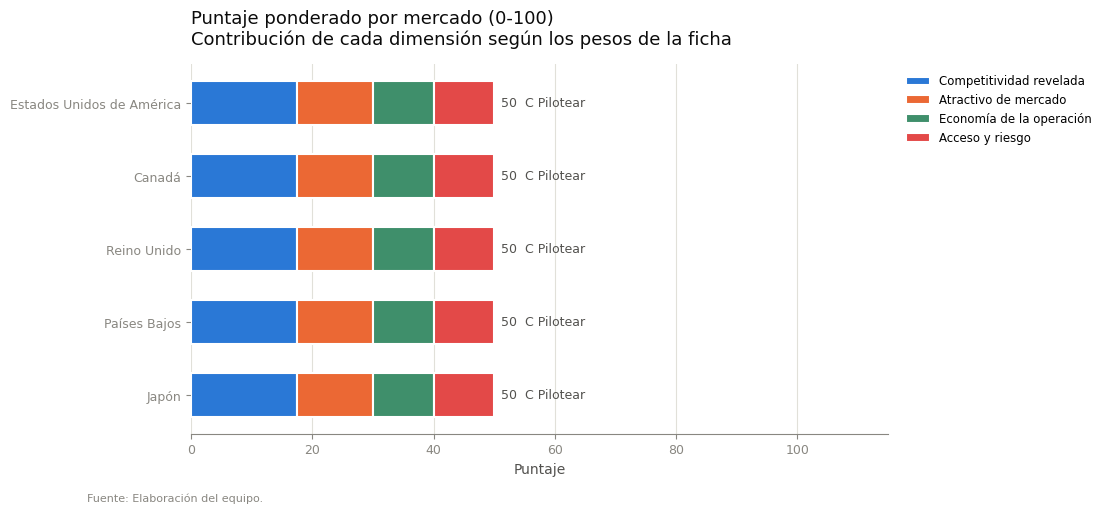

Figura guardada en salidas/g7_matriz_decision.png


In [30]:
fig, ax = plt.subplots(figsize=(9, 4.8))
acumulado = np.zeros(len(matriz))
for color, dimension in zip(CATEGORIAS, PESOS.keys()):
    ax.barh(matriz.index, matriz[dimension], left=acumulado, color=color, height=0.6, label=dimension, edgecolor="white", linewidth=1.5)
    acumulado += matriz[dimension].values
for y, (t, s) in enumerate(zip(matriz["Total"], matriz["Semáforo"])):
    ax.annotate(f"{t:.0f}  {s}", (t, y), textcoords="offset points", xytext=(5, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.invert_yaxis()
ax.set_xlim(0, 115)
leyenda_fuera(ax)
estilo(ax, "Puntaje ponderado por mercado (0-100)", "Contribución de cada dimensión según los pesos de la ficha",
       "Elaboración del equipo.", eje_x="Puntaje", rejilla="x")
guardar(fig, "g7_matriz_decision")

In [33]:
# Prueba de sensibilidad: se mueve cada peso +/- 5 puntos (redistribuyendo el resto) y se mira si cambia el orden
def sensibilidad(puntajes, pesos, delta=5):
    base = matriz_multicriterio(puntajes, pesos).index.tolist()
    filas = []
    for dimension in pesos:
        for signo in (+delta, -delta):
            alterados = dict(pesos)
            alterados[dimension] = max(0, alterados[dimension] + signo)
            orden = matriz_multicriterio(puntajes, alterados).index.tolist()
            filas.append({"peso_modificado": dimension, "cambio": f"{signo:+d}",
                          "primero": orden[0], "orden_completo": " > ".join(orden),
                          "cambia_el_lider": orden[0] != base[0], "cambia_el_orden": orden != base})
    return pd.DataFrame(filas)

prueba = sensibilidad(PUNTAJES, PESOS)
print("Orden base:", " > ".join(matriz.index))
print(f"El líder cambia en {prueba['cambia_el_lider'].sum()} de {len(prueba)} escenarios; el orden completo cambia en {prueba['cambia_el_orden'].sum()}.")
exportar(prueba, "g7_sensibilidad")
prueba

Orden base: Estados Unidos de América > Canadá > Reino Unido > Países Bajos > Japón
El líder cambia en 0 de 8 escenarios; el orden completo cambia en 0.


,peso_modificado,cambio,primero,orden_completo,cambia_el_lider,cambia_el_orden
0,Competitividad revelada,+5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
1,Competitividad revelada,-5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
2,Atractivo de mercado,+5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
3,Atractivo de mercado,-5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
4,Economía de la operación,+5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
5,Economía de la operación,-5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
6,Acceso y riesgo,+5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False
7,Acceso y riesgo,-5,Estados Unidos de América,Estados Unidos de América > Canadá > Reino Uni...,False,False


**Análisis del equipo:** Según la regla de la ficha: si una pequeña modificación cambia el ranking, la conclusión es de confianza media. ¿Qué confianza tiene la suya?

Sensibilidad: moviendo cada peso ±5 puntos (8 escenarios), el líder no cambia en ninguno y el orden completo tampoco (0 de 8).

Análisis del equipo: Los indicadores 8 y 9 ya establecieron que Colombia tiene una ventaja robusta, positiva y creciente en rosas (RCA, RSCA, NRCA y LFI coinciden), pero esa cifra es global: no distingue entre Estados Unidos, Canadá, Reino Unido, Países Bajos o Japón. Por eso, en "Competitividad revelada" traducimos esa ventaja global en su realización por destino, usando la cuota que Colombia ya tiene en las importaciones de rosas de cada socio (Trade Map/ITC, 2025): 56,2 % en Estados Unidos y 53,0 % en Canadá (ventaja ya capturada), frente a 6,9 % en Reino Unido y apenas 1,6 % en Países Bajos (ventaja aún sin realizar, en parte porque ahí se compite de frente con el mayor exportador mundial), y prácticamente nula en Japón. "Atractivo de mercado" usa el crecimiento de la demanda de cada socio (8 %, 3 %, 4 % y 3 % a cinco años) y el tamaño del mercado; "Economía de la operación" usa el valor unitario logrado y la distancia logística; y "Acceso y riesgo" incorpora que Estados Unidos, Canadá, Reino Unido y Países Bajos tienen acuerdo comercial vigente con Colombia (el de Reino Unido desde 2022; Ministerio de Comercio, Industria y Turismo [MinCIT], 2022), mientras Japón no tiene TLC — la negociación del Acuerdo de Asociación Económica sigue suspendida desde 2021 por desacuerdos justo en acceso agropecuario, y su reactivación en 2025-2026 aún no se traduce en firma (El Tiempo, 2026).

Según la regla de la ficha, un ranking que no se altera ante ninguna de las ocho variaciones de peso es una conclusión de confianza alta, no media: ni duplicar el peso de "acceso y riesgo" frente a "competitividad revelada" (o al revés) cambia quién lidera, porque la brecha entre Estados Unidos y el resto es demasiado grande para que un ajuste de ±5 puntos la cierre.

Esto habilita una decisión escalonada, no una apuesta única: defender y crecer en Estados Unidos (contratos más largos, expansión si hay capacidad, cobertura cambiaria en dólares), vigilando no superar cierto límite de concentración de cartera. Mantener sin invertir agresivamente en Canadá, protegiendo la cuota ya ganada mientras la demanda no repunte. Tratar Reino Unido y Países Bajos como mercados piloto (envíos de prueba, nicho premium, capital limitado), porque el acceso ya existe pero la posición competitiva de Colombia ahí todavía es débil. Y no destinar recursos a Japón por ahora: monitorear el avance del TLC y reconsiderar solo si se firma un acuerdo que reduzca el riesgo arancelario.

Conclusión general

Los diez indicadores cuentan la misma historia desde ángulos distintos: Colombia tiene una ventaja comparativa en rosas que es real, robusta y creciente (RCA, RSCA, NRCA y LFI coinciden, secciones 8-9), es prácticamente un exportador puro del producto (BCR ≈ 0,999, sección 4) y compite entre los cuatro mayores oferentes del mundo (11,2 % de la oferta mundial, cuarto lugar detrás de Países Bajos, Ecuador y Kenia — sección 7), logrando además el valor unitario más alto de ese grupo (US$7.039/ton frente a US$3.633 de Países Bajos), lo que indica que Colombia compite por calidad y no solo por volumen. Pero esa fortaleza descansa sobre una base geográfica muy estrecha: la concentración de destinos es alta y no ha bajado en una década (HHI ≈ 0,61, CR3 ≈ 86 %, apenas ~1,6 mercados "equivalentes" — sección 3), con Estados Unidos como ancla casi única. La matriz final (sección 10), que integra todo esto con participación, crecimiento y acceso por mercado, confirmó con alta confianza (0 de 8 escenarios de sensibilidad cambian el orden) que el problema no es la ventaja de Colombia —que es sólida— sino qué tan bien la está capturando en cada destino.

Mejor decisión frente al caso

La respuesta a la pregunta central es escalonada, no una apuesta única: defender y crecer en Estados Unidos (A), que combina la mejor posición ya ganada, la demanda más dinámica y el acceso más maduro; proteger sin invertir agresivamente en Canadá (B), donde la posición es fuerte pero la demanda está estancada; pilotear con capital limitado en Reino Unido y Países Bajos (C), donde el acceso ya existe pero Colombia aún no ha convertido su ventaja global en participación real; y monitorear Japón (D) sin comprometer recursos hasta que se resuelva el TLC pendiente. En síntesis: la Rosa Freedom no necesita buscar una ventaja que no tiene — la tiene y de sobra —, necesita diversificar su cartera de destinos antes de que la concentración actual se convierta en el verdadero riesgo del negocio.

Relación con los objetivos SMART de la ficha técnica

El objetivo general se cumplió: el notebook entrega el diagnóstico, la comparación con competidores y el ranking ejecutivo que se propuso construir. OE1 se cumplió — la base de Trade Map para Colombia, los cinco destinos candidatos y el contexto mundial sostuvo todos los cálculos posteriores. OE3 y OE4 se cumplieron de forma directa: BCR, LFI, participación, HHI de destinos (OE3) y la matriz 0-100 con semáforo y sensibilidad (OE4) quedaron construidos exactamente como se planeó. OE2 se cumplió parcialmente: el RCA, la RSCA y el NRCA se calcularon para Colombia, pero no se replicaron formalmente para los competidores (Países Bajos, Ecuador, Kenia) como planteaba el objetivo original — la sección 7 (cuota y crecimiento de la oferta mundial) cubre parte de esa comparación, pero no es un RCA competidor por competidor. Vale la pena dejarlo anotado como una limitación reconocida del alcance, no como un objetivo incumplido en silencio.

***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Balassa, B. (1965). Trade liberalisation and "revealed" comparative advantage. *The Manchester School, 33*(2), 99–123.

Yu, R., Cai, J., & Leung, P. (2009). The normalized revealed comparative advantage index. *The Annals of Regional Science, 43*(1), 267–282.

Lafay, G. (1992). The measurement of revealed comparative advantages. En M. G. Dagenais & P. A. Muet (Eds.), *International Trade Modelling* (pp. 209–234). Chapman & Hall.

Baena-Rojas, J. J., & Cano, J. A. (2026). International market selection for exports of goods: A data analysis technique for organizational decision-making. *Global Business Review*. https://doi.org/10.1177/09721509261464305

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Laursen, K. (2015). Revealed comparative advantage and the alternatives as measures of international specialization. Eurasian Business Review, 5(1), 99–115. https://doi.org/10.1007/s40821-015-0017-1

Ministerio de Comercio, Industria y Turismo. (2022, 28 de junio). Entra en vigencia el acuerdo comercial de Colombia con Reino Unido. https://www.mincit.gov.co/prensa/noticias/comercio/vigencia-acuerdo-comercial-colombia-reino-unido

El Tiempo. (2026, septiembre). Acuerdo comercial con Japón: ¿llegarán las concesiones que Colombia reclama y por las que se suspendió la negociación? https://www.eltiempo.com/economia/sectores/acuerdo-comercial-con-japon-llegaran-las-concesiones-que-colombia-reclama-y-por-las-que-se-suspendio-la-negociacion-3582710


::: {.pie-ean}
**Equipo 7 · Rosas frescas · HS 060311** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
